In [109]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")

In [110]:
np.random.seed(42)
N = 256
tiempo = np.arange(N)

# Señal seno con 2 ciclos
ciclos = 2
amplitud = 1
seno2 = amplitud * np.sin(ciclos * 2 * np.pi * tiempo / N)

# Señal seno con 10 ciclos
ciclos = 10
amplitud = 1
seno10 = amplitud * np.sin(ciclos * 2 * np.pi * tiempo / N)

# Señal seno con 20 ciclos
ciclos = 20
amplitud = 2
seno20 = amplitud * np.sin(ciclos * 2 * np.pi * tiempo / N)

# Nivel DC
nivel_dc = np.ones(N)

# Nivel de ruido gaussiano con media 0 y desviación estándar 0.5
nivelruido = np.random.normal(loc=0, scale=0.5, size=N)

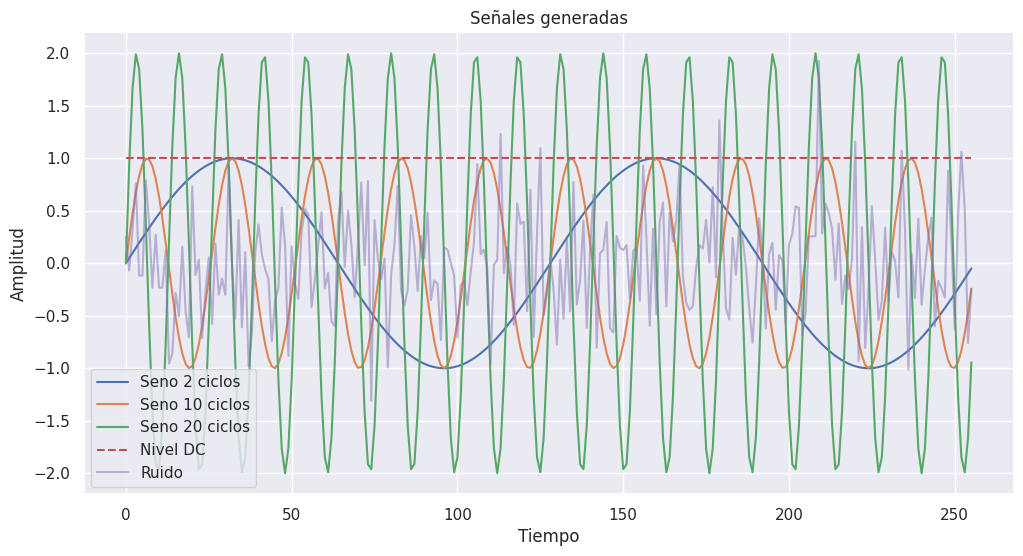

In [111]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=tiempo, y=seno2, label='Seno 2 ciclos')
sns.lineplot(x=tiempo, y=seno10, label='Seno 10 ciclos')
sns.lineplot(x=tiempo, y=seno20, label='Seno 20 ciclos')
sns.lineplot(x=tiempo, y=nivel_dc, label='Nivel DC', linestyle='dashed')
sns.lineplot(x=tiempo, y=nivelruido, label='Ruido', alpha=0.5)
plt.title('Señales generadas')
plt.xlabel('Tiempo')
plt.ylabel('Amplitud')
plt.legend()
plt.show()

In [112]:
# Serie combinada
serie = seno2 + seno10 + seno20 + nivel_dc + nivelruido
serie_fft = np.abs(np.fft.fft(serie))

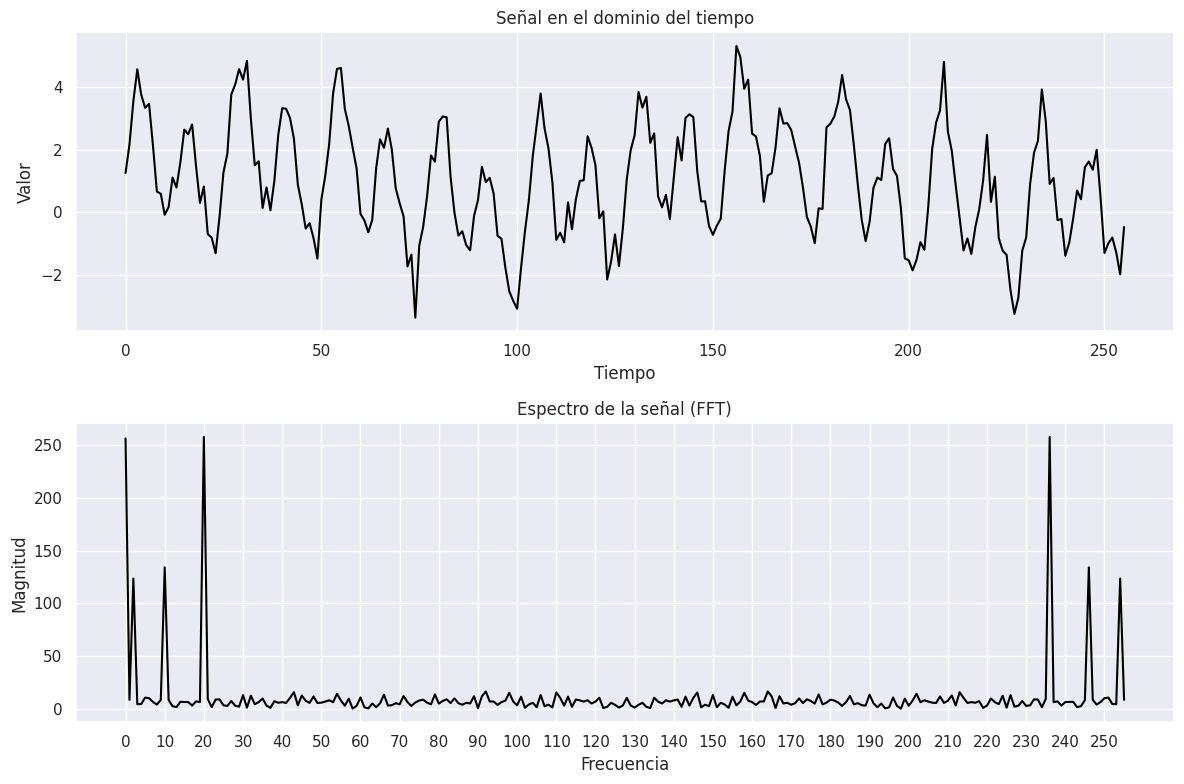

In [113]:
_, axes = plt.subplots(2, 1, figsize=(12, 8))

sns.lineplot(x=tiempo, y=serie, ax=axes[0], color='black')
axes[0].set_title("Señal en el dominio del tiempo")
axes[0].set_xlabel("Tiempo")
axes[0].set_ylabel("Valor")
sns.lineplot(x=tiempo, y=serie_fft, ax=axes[1], color='black')
axes[1].set_title("Espectro de la señal (FFT)")
axes[1].set_xlabel("Frecuencia")
axes[1].set_ylabel("Magnitud")
axes[1].set_xticks(range(0, N, 10))

plt.tight_layout()
plt.show()

- Pico en el 0: nivel DC, constante
- Pico en el 2 y en el 10: indican presencia de componentes que forman 2 y 10 ciclos de magnitud similar respectivamente
- Pico en el 20: indica componente cíclico de 20, con el doble de magnitud que los de 2 y 10, sugiriendo una amplitud del doble
- Ruido

# Aplicación de filtros

## Pasa-Altos

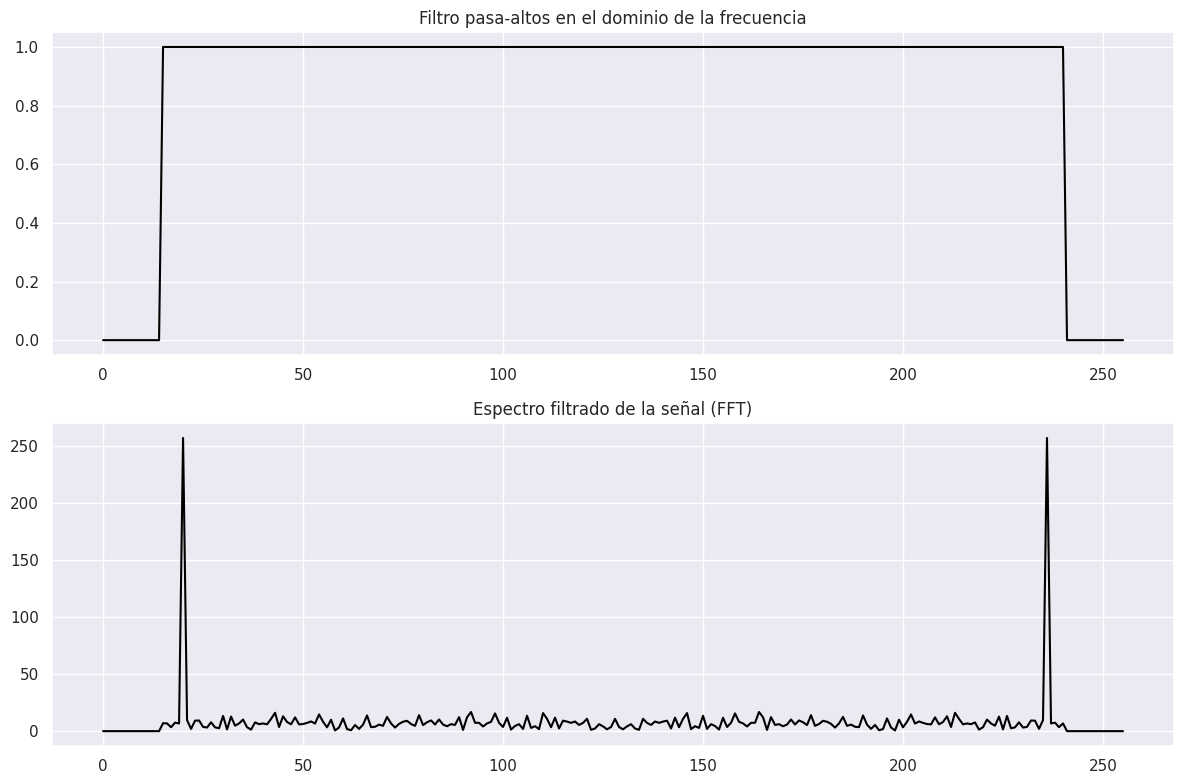

In [114]:
# Filtrado en el dominio de la frecuencia (pasa altos, elimina bajos)
filtro_dom_freq = np.zeros(N)
rango_pasa_altos = 15
filtro_dom_freq[rango_pasa_altos:-rango_pasa_altos] = 1

# Aplicar filtro en la frecuencia
serie_fft_filtrado = filtro_dom_freq * serie_fft

_, axes = plt.subplots(2, 1, figsize=(12, 8))

sns.lineplot(x=tiempo, y=filtro_dom_freq, ax=axes[0], color='black')
axes[0].set_title("Filtro pasa-altos en el dominio de la frecuencia")
sns.lineplot(x=tiempo, y=serie_fft_filtrado, ax=axes[1], color='black')
axes[1].set_title("Espectro filtrado de la señal (FFT)")

plt.tight_layout()
plt.show()

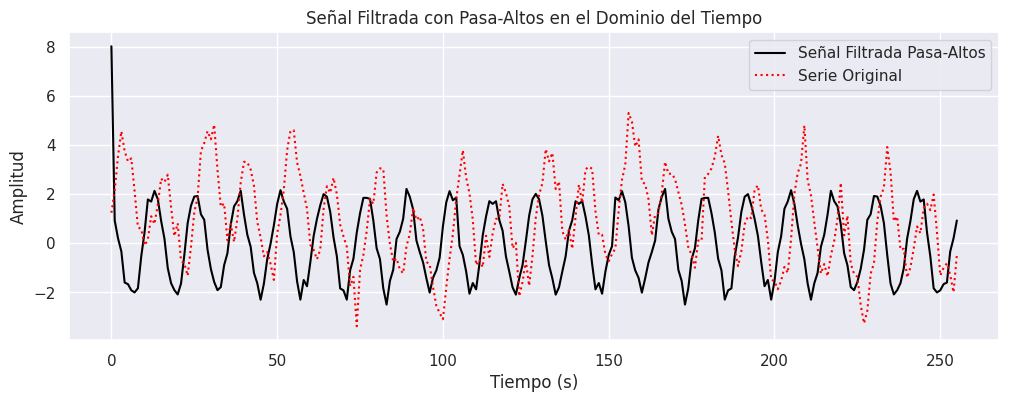

In [115]:
# Transformada inversa para recuperar la señal filtrada
serie_fft_filtrada_tiempo = np.fft.ifft(serie_fft_filtrado).real

# Graficar
plt.figure(figsize=(12, 4))
sns.lineplot(x=tiempo, y=serie_fft_filtrada_tiempo, label="Señal Filtrada Pasa-Altos", color='black')
sns.lineplot(x=tiempo, y=serie, label="Serie Original", color='red', linestyle='dotted')
plt.title("Señal Filtrada con Pasa-Altos en el Dominio del Tiempo")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.show()

Le eliminó las componentes de baja frecuencia (principalmente los picos de 2 y 10 que vimos antes)

---

## Pasa-Bajos

Buscamos ahora eliminar el ruido

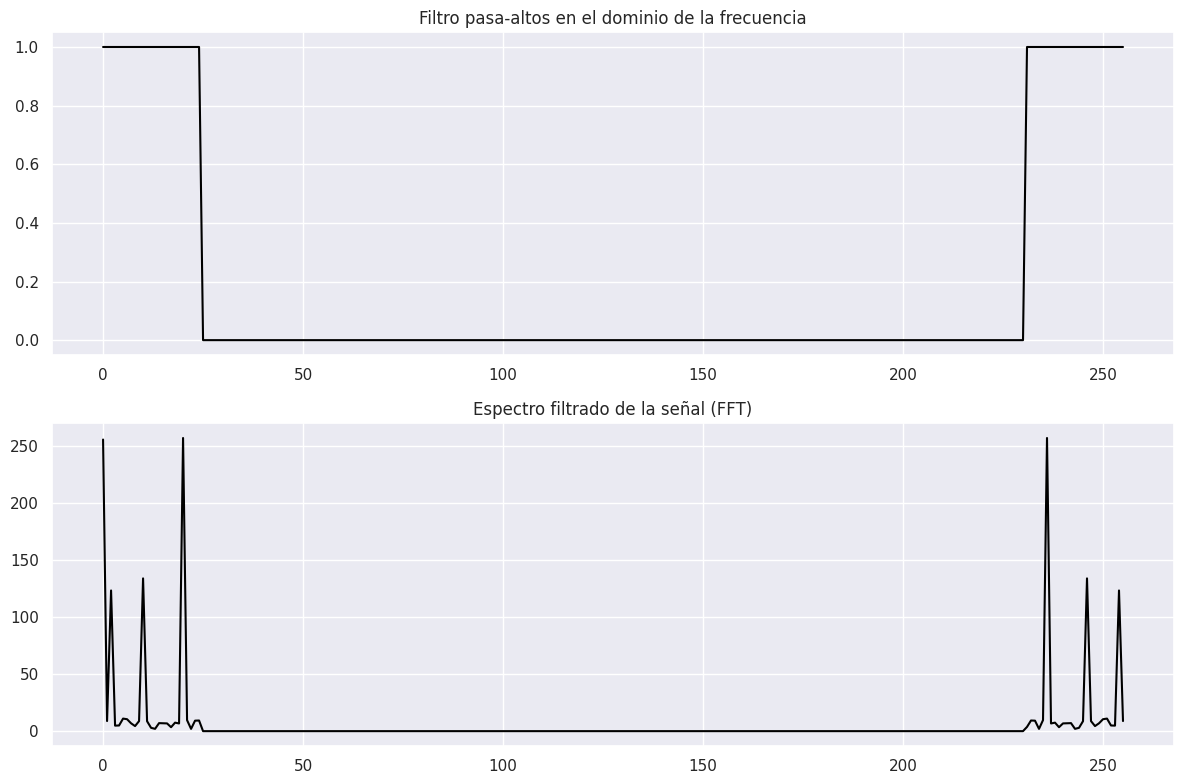

In [116]:
# Filtrado en el dominio de la frecuencia (pasa bajos)
filtro_dom_freq = np.ones(N)
rango_filtrado = 25
filtro_dom_freq[rango_filtrado:-rango_filtrado] = 0

# Aplicar filtro en la frecuencia
serie_fft_filtrado = filtro_dom_freq * serie_fft

_, axes = plt.subplots(2, 1, figsize=(12, 8))

sns.lineplot(x=tiempo, y=filtro_dom_freq, ax=axes[0], color='black')
axes[0].set_title("Filtro pasa-altos en el dominio de la frecuencia")
sns.lineplot(x=tiempo, y=serie_fft_filtrado, ax=axes[1], color='black')
axes[1].set_title("Espectro filtrado de la señal (FFT)")

plt.tight_layout()
plt.show()

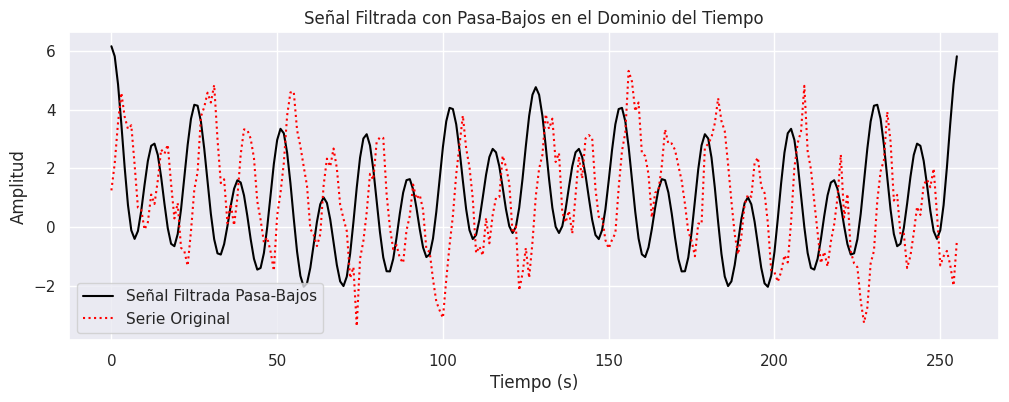

In [117]:
# Transformada inversa para recuperar la señal filtrada
serie_fft_filtrada_tiempo = np.fft.ifft(serie_fft_filtrado).real

# Graficar
plt.figure(figsize=(12, 4))
sns.lineplot(x=tiempo, y=serie_fft_filtrada_tiempo, label="Señal Filtrada Pasa-Bajos", color='black')
sns.lineplot(x=tiempo, y=serie, label="Serie Original", color='red', linestyle='dotted')
plt.title("Señal Filtrada con Pasa-Bajos en el Dominio del Tiempo")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.show()

No entiendo los picos que aparecen en el inicio. Y hay un desfase con la original. Esto se ve tanto el el filtrado pasa altos como en el pasa bajos.

Aca printeo las series donde se ven los picos.

In [118]:
serie_fft_filtrado

array([256.10113469,   8.87621546, 123.55158322,   4.84366193,
         4.97886535,  11.02533346,  10.48600749,   6.89444861,
         4.45854239,   8.82725721, 134.1647986 ,   8.74779649,
         2.91614903,   2.02845356,   7.04473289,   6.96533138,
         6.79810792,   3.46565758,   7.46654421,   6.75632287,
       257.47245163,   9.67069112,   2.00705401,   9.20509714,
         9.35274962,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.  

In [119]:
serie_fft_filtrada_tiempo

array([ 6.15559057e+00,  5.81362470e+00,  4.86213336e+00,  3.50653692e+00,
        2.03430385e+00,  7.46971781e-01, -1.10066646e-01, -4.02870140e-01,
       -1.36143071e-01,  5.53705155e-01,  1.43711015e+00,  2.25125728e+00,
        2.76610069e+00,  2.84018724e+00,  2.45297000e+00,  1.70646919e+00,
        7.96845189e-01, -3.62705924e-02, -5.69751703e-01, -6.51565934e-01,
       -2.37124079e-01,  6.00648167e-01,  1.68905699e+00,  2.79619709e+00,
        3.68423448e+00,  4.16282093e+00,  4.13052338e+00,  3.59533677e+00,
        2.67037270e+00,  1.54646795e+00,  4.48471647e-01, -4.14694622e-01,
       -8.95077899e-01, -9.36093148e-01, -5.81950133e-01,  3.55558694e-02,
        7.29626544e-01,  1.30298483e+00,  1.59435048e+00,  1.51645308e+00,
        1.07698331e+00,  3.77585248e-01, -4.09167097e-01, -1.07990264e+00,
       -1.44878712e+00, -1.39303718e+00, -8.84925037e-01, -2.39119658e-03,
        1.08487271e+00,  2.15134865e+00,  2.96582352e+00,  3.34430654e+00,
        3.19329525e+00,  